<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Stochastic-modeling-and-derivatives---TD-7---solutions" data-toc-modified-id="Stochastic-modeling-and-derivatives---TD-7---solutions-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Stochastic modeling and derivatives - TD 7 - solutions</a></span><ul class="toc-item"><li><span><a href="#Fonction-de-pricing-de-call-Black-Scholes-(rappel)" data-toc-modified-id="Fonction-de-pricing-de-call-Black-Scholes-(rappel)-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Fonction de pricing de call Black-Scholes (rappel)</a></span></li><li><span><a href="#Calcul-de-volatilité-implicite-par-méthode-de-Newton-(rappel)" data-toc-modified-id="Calcul-de-volatilité-implicite-par-méthode-de-Newton-(rappel)-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Calcul de volatilité implicite par méthode de Newton (rappel)</a></span></li></ul></li><li><span><a href="#Prix-de-call-dans-un-modèle-Displaced-Log-Normal-(voir-slide-11-du-cours-7)" data-toc-modified-id="Prix-de-call-dans-un-modèle-Displaced-Log-Normal-(voir-slide-11-du-cours-7)-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Prix de call dans un modèle Displaced Log Normal (voir slide 11 du cours 7)</a></span><ul class="toc-item"><li><span><a href="#A-COMPLETER" data-toc-modified-id="A-COMPLETER-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>A COMPLETER</a></span></li><li><span><a href="#Sanity-check:-quelques-tests-de-prix-DLN" data-toc-modified-id="Sanity-check:-quelques-tests-de-prix-DLN-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Sanity check: quelques tests de prix DLN</a></span></li></ul></li><li><span><a href="#Prix-de-call-dans-un-modèle-de-Merton-(voir-slide-14-du-cours-7)" data-toc-modified-id="Prix-de-put-dans-un-modèle-de-Merton-(voir-slide-14-du-cours-7)-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Prix de put dans un modèle de Merton (voir slide 14 du cours 7)</a></span><ul class="toc-item"><li><span><a href="#A-COMPLETER" data-toc-modified-id="A-COMPLETER-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>A COMPLETER</a></span></li><li><span><a href="#Sanity-check:-quelques-tests-de-prix-de-Merton" data-toc-modified-id="Sanity-check:-quelques-tests-de-prix-de-Merton-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Sanity check: quelques tests de prix de Merton</a></span></li></ul></li><li><span><a href="#Affichage-des-surfaces-de-prix-BS,-DLN-et-Merton-en-fonction-de-la-maturité-T-et-du-strike-K" data-toc-modified-id="Affichage-des-surfaces-de-prix-BS,-DLN-et-Merton-en-fonction-de-la-maturité-T-et-du-strike-K-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Affichage des surfaces de prix BS, DLN et Merton en fonction de la maturité T et du strike K</a></span><ul class="toc-item"><li><span><a href="#A-COMPLETER" data-toc-modified-id="A-COMPLETER-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>A COMPLETER</a></span></li></ul></li><li><span><a href="#Affichage-des-surfaces-de-volatilité-implicite-DLN-et-Merton-en-fonction-de-la-maturité-T-et-de-la-log-moneyness" data-toc-modified-id="Affichage-des-surfaces-de-volatilité-implicite-DLN-et-Merton-en-fonction-de-la-maturité-T-et-de-la-log-moneyness-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Affichage des surfaces de volatilité implicite DLN et Merton en fonction de la maturité T et de la log-moneyness</a></span><ul class="toc-item"><li><span><a href="#A-COMPLETER" data-toc-modified-id="A-COMPLETER-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>A COMPLETER</a></span></li></ul></li></ul></div>

# Stochastic modeling and derivatives - TD 7

Dans ce TP, l'objectif est de calculer les formules de prix de put dans 
- un modèle Displaced Log Normal
- un modèle de Merton

Puis de calculer numériquement les surfaces de volatilité implicite de ces modèles.

Dans tout le TP, on suppose (pour simplifier) que les taux d'intérêt et de repo sont nuls.

## Fonction de pricing de call Black-Scholes (rappel)

In [23]:
import numpy as np

import scipy.stats as sps

####################################################
##################### CALL PART ####################
####################################################

def Call_BS_core(tau, K, DF, F, sigma):
    """
    Prix du call Black-Scholes en fonction de
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    d_plus = np.log(F/K)/sigma_sqrt_tau + sigma_sqrt_tau/2.
    d_minus = d_plus - sigma_sqrt_tau
    prix_call = DF * (F * sps.norm.cdf(d_plus) - K * sps.norm.cdf(d_minus))
    return prix_call

def Digital_Call_BS_core(tau, K, DF, F, sigma):
    """
    Prix du call Black-Scholes en fonction de
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    d_plus = np.log(F/K)/sigma_sqrt_tau + sigma_sqrt_tau/2.
    d_minus = d_plus - sigma_sqrt_tau
    prix_call = DF * (1* sps.norm.cdf(d_minus))
    return prix_call


def Digital_Call_BS(t, S, T, K, r, q, sigma):
    """
    Prix du Call Black-Scholes en fonction des paramètres BS usuels.
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp((r-q)*tau)
    
    return Digital_Call_BS_core(tau, K, DF, F, sigma)

def Call_BS(t, S, T, K, r, q, sigma):
    """
    Prix du Call Black-Scholes en fonction des paramètres BS usuels.
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp((r-q)*tau)
    
    return Call_BS_core(tau, K, DF, F, sigma)

def Call_BS_zero_rate(t, S, T, K, sigma):
    """
    Prix du call Black-Scholes en fonction des paramètres BS usuels mais avec taux r=q=0
    """
    tau = T - t
    DF = 1
    F = S
    return Call_BS_core(tau, K, DF, F, sigma)

####################################################
##################### PUT PART #####################
####################################################

def Put_BS_core(tau, K, DF, F, sigma):
    """
    Prix du Call Black-Scholes en fonction de
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)

    d_plus = np.log(F/K)/sigma_sqrt_tau + sigma_sqrt_tau/2.
    
    d_minus = d_plus - sigma_sqrt_tau

    ####################
    ## TO DO: compléter
    ####################
    prix_put = DF * (K * sps.norm.cdf(-d_minus) - F * sps.norm.cdf(-d_plus))

    return prix_put

def Put_BS(t, S, T, K, r, q, sigma):
    """
    Prix du Call Black-Scholes en fonction des paramètres BS usuels.
    """
    tau = T - t
    DF = np.exp(-r*tau)
    F = S * np.exp((r-q)*tau)
    
    return Put_BS_core(tau, K, DF, F, sigma)


def Put_BS_zero_rate(t, S, T, K, sigma):
    """
    Prix du put Black-Scholes en fonction des paramètres BS usuels mais avec taux r=q=0
    """
    tau = T - t
    DF = 1
    F = S
    return Put_BS_core(tau, K, DF, F, sigma)

In [24]:
t = 0
S = 99.770000
T = 0.297000
K = 99.880000
r = 0.027000
q = 0.065000
sigma = 0.279200
Digital_Call_BS(t, S, T, K, r, q, sigma)

np.float64(0.4339340947754726)

## Calcul de volatilité implicite par méthode de Newton (rappel)

In [2]:
def Vega_core(tau, K, DF, F, sigma):
    """
    Vega d'un call Black-Scholes en fonction de
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    d_plus = np.log(F/K) / sigma_sqrt_tau + sigma_sqrt_tau / 2.
    vega = DF * F * np.sqrt(tau) * np.exp(- d_plus**2 / 2) / np.sqrt(2*np.pi)
    return vega

def Vega_zero_rate(t, S, T, K, r, q, sigma):
    """
    Vega d'un call Black-Scholes en fonction des paramètres BS usuels mais avec taux r=q=0
    """
    tau = T - t
    DF = 1
    F = S
    return Vega_core(tau, K, DF, F, sigma)

####################################################
##################### CALL PART ####################
####################################################

def volImplCallCore_Newton(tau, K, DF, F, price, initial_point='automatic', prix_tol = 1.e-8, max_iter=50):
    """
    Volatilité implicite d'un call de prix = price, lorsque les autres paramètres sont:
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    
    Méthode: Newton.
    """
    if initial_point == 'automatic':
        vol = np.sqrt( 2/tau * np.abs(np.log(F/K)) )
    else:
        vol = initial_point
    
    if vol==0: 
        vol=0.0001 # pour eviter un point initial nul si option ATM
        
    current_price = Call_BS_core(tau, K, DF, F, vol)    
    critere_arret = np.abs(current_price - price)
    iterations = 0
    
    while ( (critere_arret > prix_tol) & (iterations < max_iter) ):
        iterations = iterations + 1
        vol = vol - (current_price - price) / Vega_core(tau, K, DF, F, vol)
        current_price = Call_BS_core(tau, K, DF, F, vol)
        critere_arret = np.abs(current_price - price)

    return vol, iterations

####################################################
##################### PUT PART #####################
####################################################

def volImplPutCore_Newton(tau, K, DF, F, price, initial_point='automatic', prix_tol = 1.e-8, max_iter=50):
    """
    Volatilité implicite d'un put de prix = price, lorsque les autres paramètres sont:
    
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    
    Méthode: Newton.
    """
    if initial_point == 'automatic':
        vol = np.sqrt( 2/tau * np.abs(np.log(F/K)) )
    else:
        vol = initial_point
    
    if vol==0: 
        vol=0.0001 # pour eviter un point initial nul si option ATM
        
    current_price = Put_BS_core(tau, K, DF, F, vol)    
    critere_arret = np.abs(current_price - price)
    iterations = 0
    
    while ( (critere_arret > prix_tol) & (iterations < max_iter) ):
        iterations = iterations + 1
        vol = vol - (current_price - price) / Vega_core(tau, K, DF, F, vol)
        current_price = Put_BS_core(tau, K, DF, F, vol)
        critere_arret = np.abs(current_price - price)

    return vol, iterations

# Prix de call dans un modèle Displaced Log Normal (voir slide 11 du cours 7)
## A COMPLETER

In [3]:
####################################################
##################### CALL PART ####################
####################################################

def Call_DLN_zero_rate(t, S, T, K, sigma, a):
    """
    Prix du call dans un modèle Log Normale Deplace mais avec taux r=q=0
    """    
    return Call_BS_zero_rate(t, S + a, T, K + a, sigma)

def Call_DLN(t, S, T, K, r, q, sigma, a):
    """
    Prix du call dans un modèle Log Normale Deplace
    """    
    return Call_BS(t, S + a, T, K + a, r, q, sigma)

####################################################
##################### PUT PART #####################
####################################################

def Put_DLN_zero_rate(t, S, T, K, sigma, a):
    """
    Prix du put dans un modèle Log Normale Deplace mais avec taux r=q=0
    """    
    return Put_BS_zero_rate(t, S + a, T, K + a, sigma)

def Put_DLN(t, S, T, K, r, q, sigma, a):
    """
    Prix du put dans un modèle Log Normale Deplace
    """    
    return Put_BS(t, S + a, T, K + a, r, q, sigma)

In [31]:
########################################################################################
# We consider two assets S1,S2
#  which (vector) volatilities (with respect to the two Brownian motions W^1,W^2
#  under the historical probability measure) are respectively given by σ(1)=(A B)
#  and σ(2)=(X Y).
#  Compute the instantaneous correlation between the two assets (a number between -1 and 1, with expected accuracy = 0.01).
#########################################################################################
def volatility_spot(vecteur_vol):
    return np.sqrt(np.array(vecteur_vol) @ np.array(vecteur_vol).T)

def correlation_spot(vecteur_vol_1, vecteur_vol_2):
    return (np.array(vecteur_vol_1) @ np.array(vecteur_vol_2)) / (volatility_spot(vecteur_vol_1) * volatility_spot(vecteur_vol_2))

def compute_product_volatility(vol_1, vol_2, correl):
    return np.sqrt(vol_1**2 + vol_2**2 + 2 * correl * vol_1 * vol_2)

def compute_divide_volatility(vol_1, vol_2, correl):
    return np.sqrt(vol_1**2 + vol_2**2 - 2 * correl * vol_1 * vol_2)

vecteur_vol_1 = [-0.093000, -0.092000]
vecteur_vol_2 = [0.282000, -0.100000]

print('correlation spot :', correlation_spot(vecteur_vol_1, vecteur_vol_2))

vol_1 = 0.2401
vol_2 = 0.1012
correl = -0.61

print('spot volatility :', compute_product_volatility(vol_1, vol_2, correl))

correlation spot : -0.4349905424105559
spot volatility : 0.19556519015407625


## Sanity check: quelques tests de prix DLN

In [27]:
t = 0
S = 99.760000
T = 0.314000
K = 90.980000
sigmaDLN = 0.206700
a = 35.190000

r = 0.00
q = 0.00


tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp((r-q)*tau)


SpotVolNow= sigmaDLN * (S+a) / S
sigmaBS = SpotVolNow # pour avoir des niveaux de vol spot comparables entre BS et DLN

prixcall_BS = Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=SpotVolNow)
prixcall_DLN = Call_DLN_zero_rate(t=t, S=S, T=T, K=K, sigma=sigmaDLN, a=a)
vol_Newton_BS, iterations_BS = volImplCallCore_Newton(tau, K, DF, F, prixcall_BS, initial_point='automatic', prix_tol = 1.e-8)
vol_Newton_DLN, iterations_DLN = volImplCallCore_Newton(tau, K, DF, F, prixcall_DLN, initial_point='automatic', prix_tol = 1.e-8)

print("Quelques tests.")
print(" "*5+"Prix des call: BS %1.8f vs DLN %1.8f" %(prixcall_BS, prixcall_DLN))
print(" "*5+"Vols implicites par Newton: %1.8f vs %1.8f"%(vol_Newton_BS,vol_Newton_DLN))
print(" "*5+"Nombre iterations dans la méthode de Newton: %2.0f vs %2.0f" %(iterations_BS, iterations_DLN))
print(" "*5+"Sanity-check: Re-pricing des call: BS %1.8f vs DLN %1.8f" %(Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=vol_Newton_BS),
                                                            Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=vol_Newton_DLN)))

Quelques tests.
     Prix des call: BS 11.34310479 vs DLN 11.40733639
     Vols implicites par Newton: 0.27961272 vs 0.28320107
     Nombre iterations dans la méthode de Newton:  4 vs  4
     Sanity-check: Re-pricing des call: BS 11.34310479 vs DLN 11.40733639


In [6]:
T = 1/12
K = 110
t = 0
S = 100
r = 0.00
q = 0.00
a = 60

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp((r-q)*tau)

sigmaDLN = 0.2
SpotVolNow= sigmaDLN * (S+a) / S
sigmaBS = SpotVolNow # pour avoir des niveaux de vol spot comparables entre BS et DLN

prixput_BS = Put_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=SpotVolNow)
prixput_DLN = Put_DLN_zero_rate(t=t, S=S, T=T, K=K, sigma=sigmaDLN, a=a)
vol_Newton_BS, iterations_BS = volImplPutCore_Newton(tau, K, DF, F, prixput_BS, initial_point='automatic', prix_tol = 1.e-8)
vol_Newton_DLN, iterations_DLN = volImplPutCore_Newton(tau, K, DF, F, prixput_DLN, initial_point='automatic', prix_tol = 1.e-8)

print("Quelques tests.")
print(" "*5+"Prix des put: BS %1.8f vs DLN %1.8f" %(prixput_BS, prixput_DLN))
print(" "*5+"Vols implicites par Newton: %1.8f vs %1.8f"%(vol_Newton_BS,vol_Newton_DLN))
print(" "*5+"Nombre iterations dans la méthode de Newton: %2.0f vs %2.0f" %(iterations_BS, iterations_DLN))
print(" "*5+"Sanity-check: Re-pricing des put: BS %1.8f vs DLN %1.8f" %(Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=vol_Newton_BS),
                                                            Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=vol_Newton_DLN)))

Quelques tests.
     Prix des put: BS 10.75902729 vs DLN 10.72035649
     Vols implicites par Newton: 0.32000000 vs 0.31449159
     Nombre iterations dans la méthode de Newton:  5 vs  5
     Sanity-check: Re-pricing des put: BS 0.75902729 vs DLN 0.72035649


# Prix de call dans un modèle de Merton (voir slide 14 du cours 7)
## A COMPLETER

In [7]:
import math as math
def Call_Merton_zero_rate(t, S, T, K, sigma, lamb, m, alpha):
    """
    Prix du call dans un modèle Merton avec taux r=q=0
    """    
    tau=T-t
    sum=0
    for k in range(10):

        prix_k = Call_BS_zero_rate(t, S*np.power(1+m, k)*np.exp(-m*lamb*tau), T, K, np.sqrt((sigma**2 + alpha**2 * k / tau)))


        sum = sum + prix_k * np.exp(-lamb * tau) * np.power(lamb * tau, k) / math.factorial(k)
    return sum

## Sanity check: quelques tests de prix de Merton

In [8]:
T = 1/12
K = 110
t = 0
S = 100
r = 0.00
q = 0.00
lamb = 1
m= 0
alpha= 0.5

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp((r-q)*tau)

prixput_BS = Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=0.2)
prixcall_Merton = Call_Merton_zero_rate(t=t, S=S, T=T, K=K, sigma=0.2, lamb=lamb, m=m, alpha=alpha)
vol_Newton_BS, iterations_BS = volImplCallCore_Newton(tau, K, DF, F, prixput_BS, initial_point='automatic', prix_tol = 1.e-8)
vol_Newton_Merton, iterations_Merton = volImplCallCore_Newton(tau, K, DF, F, prixcall_Merton, initial_point='automatic', prix_tol = 1.e-8)

print("Quelques tests.")
print(" "*5+"Prix des call: BS %1.8f vs Merton %1.8f" %(prixput_BS, prixcall_Merton))
print(" "*5+"Vols implicites par Newton: %1.8f vs %1.8f"%(vol_Newton_BS,vol_Newton_Merton))
print(" "*5+"Nombre iterations dans la méthode de Newton: %2.0f vs %2.0f" %(iterations_BS, iterations_Merton))
print(" "*5+"Sanity-Check - Re-pricing des call: BS %1.8f vs Merton %1.8f" %(Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=vol_Newton_BS),
                                                            Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=vol_Newton_Merton)))

Quelques tests.
     Prix des call: BS 0.12467892 vs Merton 1.43949786
     Vols implicites par Newton: 0.20000000 vs 0.40570508
     Nombre iterations dans la méthode de Newton:  6 vs  4
     Sanity-Check - Re-pricing des call: BS 0.12467892 vs Merton 1.43949786


# Affichage des surfaces de prix BS, DLN et Merton en fonction de la maturité T et du strike K
## A COMPLETER

In [9]:
# #%conda install -c conda-forge ipympl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import pandas as pd
#pour permettre l'interactivite avec les graphes
# %matplotlib notebook 
# %matplotlib ipympl

def Call_BS_full_zero_rate(t, S_t, T, K, sigma):
    r = 0
    q = 0
    sigma_sqrt_time = sigma * np.sqrt(T - t)
    #######################################################
    ## TO DO: compléter avec le calcul du prix du call BS
    #######################################################
    F_t = S_t * np.exp((r-q)*(T-t))
    d1 = (1/sigma_sqrt_time) * np.log(F_t/K) + 0.5 * sigma_sqrt_time
    d2 = d1 - sigma_sqrt_time
    price = np.exp(-r * (T-t)) * (F_t * sps.norm.cdf(d1) - K * sps.norm.cdf(d2))
    delta = np.exp(-q * (T-t)) * sps.norm.cdf(d1)
    vega = S_t * np.exp(-q * (T-t)) * np.sqrt(T-t) * sps.norm.pdf(d1)
    gamma = vega / (S_t**2 * sigma * (T-t))
    theta = - S_t * np.exp(-q * (T-t)) * sigma * sps.norm.pdf(d1) / (2 * np.sqrt(T-t)) + q * S_t * np.exp(-q * (T-t)) * sps.norm.cdf(d1) - r * K * np.exp(-r * (T - t)) * sps.norm.cdf(d2)
    rho = (T-t) * K * np.exp(-r*(T-t)) * sps.norm.cdf(d2)

    return {'price':price, 'delta':delta, 'vega':vega, 'gamma':gamma, 'theta':theta, 'rho':rho} 

In [16]:
#######################################################
####### ESPERANCE de exp(b + a * W_t) égale à 1 #######
#######################################################

a = 6.120000
t = 0.510000

b = -0.5 * (a**2) * t
print(b)

t = 0

-9.550872


In [37]:

data = pd.read_csv('download.csv', delimiter=';')

maturity = 0.480000
forward = 149.700000
q = 0
t = 0


# Call_BS_zero_rate(t, S, T, K, sigma)

# (t, S_t, T, K, sigma)

data['log_moneyness'] = data.apply(lambda x: np.log(forward/x.Strike), axis=1)
data['price'] = data.apply(lambda x: Call_BS_full_zero_rate(t=t, S_t=forward, T=maturity, K=x.Strike, sigma=x.IV)['price'], axis=1)
data['delta'] = data.apply(lambda x: Call_BS_full_zero_rate(t=t, S_t=forward, T=maturity, K=x.Strike, sigma=x.IV)['delta'], axis=1)
data['delta_recomputed'] = data.apply(lambda x:  np.exp(-q * (T-t)) * sps.norm.cdf((1/(x.IV * np.sqrt(maturity - t))) * np.log(forward/x.Strike) + 0.5 * x.IV * np.sqrt(maturity - t)), axis=1)
data['delta_cash'] = data['delta'] * forward

data['vega'] = data.apply(lambda x: Call_BS_full_zero_rate(t=t, S_t=forward, T=maturity, K=x.Strike, sigma=x.IV)['vega'], axis=1)
data['gamma'] = data.apply(lambda x: Call_BS_full_zero_rate(t=t, S_t=forward, T=maturity, K=x.Strike, sigma=x.IV)['gamma'], axis=1)
data['theta'] = data.apply(lambda x: Call_BS_full_zero_rate(t=t, S_t=forward, T=maturity, K=x.Strike, sigma=x.IV)['theta'], axis=1)


display(data)

x0 = 0.25
tmp = data[['delta','IV']].dropna().sort_values('delta')  # makes delta increasing
val = np.interp(x0, tmp['delta'].to_numpy(), tmp['IV'].to_numpy())
val_call = val

x0 = -0.25
data['delta_put'] = data['delta'] - 1
tmp_put = data[['delta_put','IV']].dropna().sort_values('delta_put')  # makes delta increasing
val_put = np.interp(x0, tmp_put['delta_put'].to_numpy(), tmp_put['IV'].to_numpy())

risk_reversal = val_call - val_put
print('25-delta risk reversal :', risk_reversal)
print('25-delta call IV :', val_call)
print('25-delta put IV :', val_put)

,Strike,IV,Unnamed: 2,log_moneyness,price,delta,delta_recomputed,delta_cash,vega,gamma,theta
0,36.915566,0.993415,NaN,1.400000,113.162619,0.991302,0.991302,148.397981,2.446539,2.289479e-04,-2.531697
1,37.019178,0.992577,NaN,1.397197,113.061676,0.991240,0.991240,148.388598,2.461991,2.305883e-04,-2.545537
2,37.123081,0.991738,NaN,1.394394,112.960461,0.991177,0.991177,148.379148,2.477536,2.322406e-04,-2.559444
3,37.227275,0.990898,NaN,1.391592,112.858974,0.991113,0.991113,148.369630,2.493175,2.339047e-04,-2.573419
4,37.331762,0.990058,NaN,1.388789,112.757215,0.991049,0.991049,148.360037,2.508919,2.355815e-04,-2.587474
...,...,...,...,...,...,...,...,...,...,...,...
995,600.295528,0.422725,NaN,-1.388789,0.000018,0.000002,0.000002,0.000323,0.001074,2.361116e-07,-0.000473
996,601.980398,0.422898,NaN,-1.391592,0.000017,0.000002,0.000002,0.000312,0.001037,2.279430e-07,-0.000457
997,603.669997,0.423071,NaN,-1.394394,0.000017,0.000002,0.000002,0.000300,0.001001,2.200507e-07,-0.000441
998,605.364338,0.423244,NaN,-1.397197,0.000016,0.000002,0.000002,0.000290,0.000967,2.124257e-07,-0.000426


25-delta risk reversal : -0.13096977410461158
25-delta call IV : 0.44068766879926274
25-delta put IV : 0.5716574429038743


In [36]:
display(data[(data['delta']<=0.255) & (data['delta']>=0.245)])
display(data[(data['delta_put']>=-0.255) & (data['delta_put']<=-0.245)])

,Strike,IV,Unnamed: 2,log_moneyness,price,delta,delta_recomputed,delta_cash,vega,gamma,theta,delta_put
589,192.382224,0.441017,NaN,-0.250851,5.964184,0.251996,0.251996,37.723862,33.097270,0.006977,-15.204645,-0.748004
590,192.922190,0.440472,NaN,-0.253654,5.857737,0.248693,0.248693,37.229285,32.866524,0.006937,-15.079983,-0.751307
591,193.463671,0.439931,NaN,-0.256456,5.752633,0.245407,0.245407,36.737417,32.633500,0.006896,-14.954675,-0.754593


,Strike,IV,Unnamed: 2,log_moneyness,price,delta,delta_recomputed,delta_cash,vega,gamma,theta,delta_put
430,123.203628,0.573904,NaN,0.194795,37.238149,0.754499,0.754499,112.948570,32.640188,0.005287,-19.512848,-0.245501
431,123.549428,0.572869,NaN,0.191992,36.992176,0.752438,0.752438,112.639990,32.786730,0.005321,-19.565105,-0.247562
432,123.896198,0.571835,NaN,0.189189,36.746264,0.750360,0.750360,112.328946,32.933031,0.005354,-19.616938,-0.249640
433,124.243942,0.570803,NaN,0.186386,36.500453,0.748266,0.748266,112.015401,33.079082,0.005387,-19.668374,-0.251734
434,124.592661,0.569772,NaN,0.183584,36.254718,0.746155,0.746155,111.699370,33.224847,0.005421,-19.719362,-0.253845


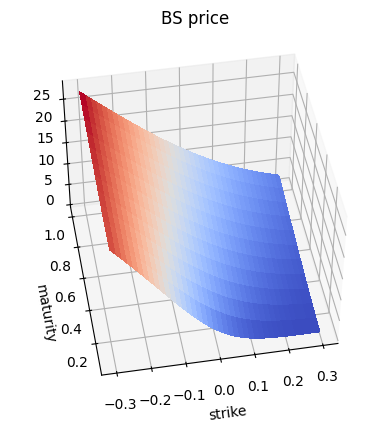

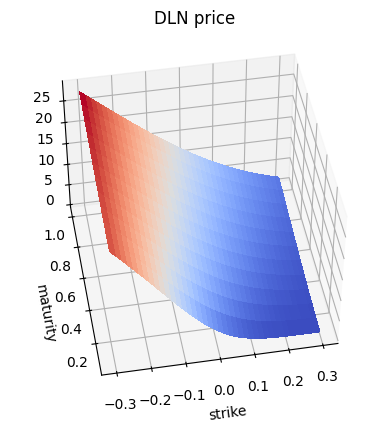

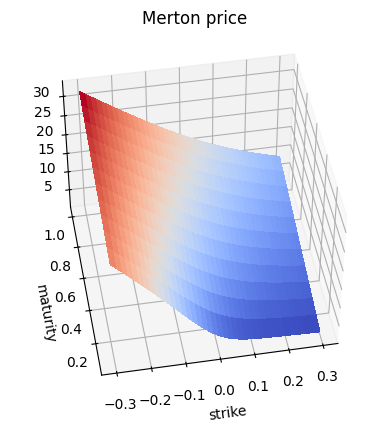

In [13]:
import matplotlib.pyplot as plt
from matplotlib import cm

# parametres de pricing
t = 0
S = 100
r = 0.00
q = 0.00
a = 60 # pour DLN
lamb = 1 # pour Merton
m= 0
alpha= 0.5
sigmaMerton=0.2

logmoneyness_grid=np.linspace(-0.3, 0.3, 41)
maturity_grid=np.linspace(1/12, 1, 12)
X, Y = np.meshgrid(logmoneyness_grid, maturity_grid)
BS_price = 0*X*Y
DLN_price= 0*X*Y
Merton_price= 0*X*Y

sigmaDLN =0.2
SpotVolNow= sigmaDLN * (S + a) / S # COMPLETER
sigmaBS = SpotVolNow # pour avoir des niveaux de vol spot comparables entre BS et DLN

for index_m in range(len(logmoneyness_grid)):
    for index_tau in range(len(maturity_grid)):
        T= maturity_grid[index_tau]
        K= S * np.exp(logmoneyness_grid[index_m])
        BS_price[index_tau][index_m]= Call_BS_zero_rate(t=t, S=S, T=T, K=K, sigma=sigmaBS)
        DLN_price[index_tau][index_m]= Call_DLN_zero_rate(t=t, S=S, T=T, K=K, sigma=sigmaDLN, a=a)
        Merton_price[index_tau][index_m]= Call_Merton_zero_rate(t=t, S=S, T=T, K=K, sigma=sigmaMerton, lamb=lamb, m=m, alpha=alpha)

fig1 = plt.figure()
ax1 = fig1.add_subplot(projection='3d')
ax1.view_init(elev=45., azim=-100)
surf = ax1.plot_surface(X, Y, BS_price, cmap=cm.coolwarm,linewidth=0, antialiased=False)
ax1.set_xlabel('strike')
ax1.set_ylabel('maturity')
ax1.set_title('BS price')

fig2 = plt.figure()
ax2 = fig2.add_subplot(projection='3d')
ax2.view_init(elev=45., azim=-100)
surf = ax2.plot_surface(X, Y, DLN_price, cmap=cm.coolwarm,linewidth=0, antialiased=False)
ax2.set_xlabel('strike')
ax2.set_ylabel('maturity')
ax2.set_title('DLN price')

fig3 = plt.figure()
ax3 = fig3.add_subplot(projection='3d')
ax3.view_init(elev=45., azim=-100)
surf = ax3.plot_surface(X, Y, Merton_price, cmap=cm.coolwarm,linewidth=0, antialiased=False)
ax3.set_xlabel('strike')
ax3.set_ylabel('maturity')
ax3.set_title('Merton price')

plt.show(block=True)

# Affichage des surfaces de volatilité implicite DLN et Merton en fonction de la maturité T et de la log-moneyness
## A COMPLETER

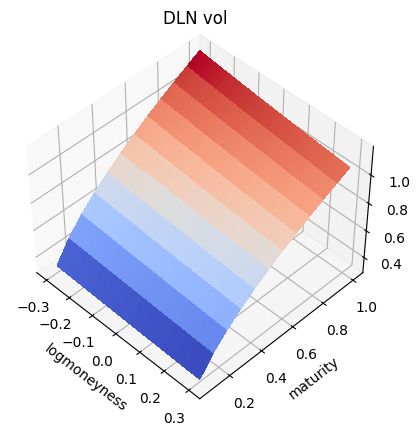

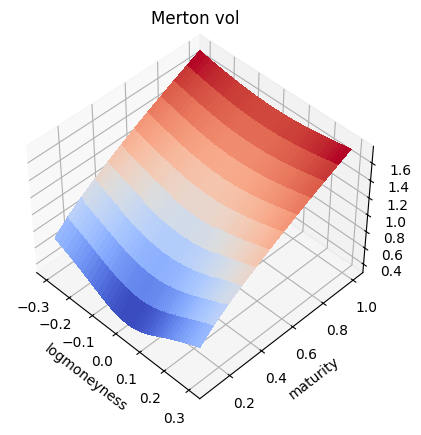

In [14]:
DLN_vol= 0*X*Y
Merton_vol= 0*X*Y

for index_m in range(len(logmoneyness_grid)):
    for index_tau in range(len(maturity_grid)):
        T= maturity_grid[index_tau]
        K= S * np.exp(logmoneyness_grid[index_m])
        DLN_vol[index_tau][index_m], iterations = volImplCallCore_Newton(tau, K, DF, F, DLN_price[index_tau][index_m], initial_point='automatic', prix_tol = 1.e-8)
        Merton_vol[index_tau][index_m], iterations = volImplCallCore_Newton(tau, K, DF, F, Merton_price[index_tau][index_m], initial_point='automatic', prix_tol = 1.e-8)

fig4 = plt.figure()
ax4 = fig4.add_subplot(projection='3d')
ax4.view_init(elev=45., azim=-45)
surf = ax4.plot_surface(X, Y, DLN_vol, cmap=cm.coolwarm,linewidth=0, antialiased=False)
ax4.set_xlabel('logmoneyness')
ax4.set_ylabel('maturity')
ax4.set_title('DLN vol')


fig5 = plt.figure()
ax5 = fig5.add_subplot(projection='3d')
ax5.view_init(elev=45., azim=-45)
surf = ax5.plot_surface(X, Y, Merton_vol, cmap=cm.coolwarm,linewidth=0, antialiased=False)
ax5.set_xlabel('logmoneyness')
ax5.set_ylabel('maturity')
ax5.set_title('Merton vol')

plt.show(block=True)